<a href="https://colab.research.google.com/github/Dalbeth/Data-Science-Cohort-20/blob/main/NLP_DBpediaWikipedia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing- Finding Similar Famous People

-Class project by Kimberly Butler



# Project Description

This project was part of the CNM Ingenuity Data Science Bootcamp. The project presented here was done by Kimberly Butler.  

This project wasd designed to give students practical experience using Natural Language Processing techniques. This project is in three parts:
- in part 1) we used a dataset in a CSV file
- in part 2) we used the Wikipedia API to directly access content
on Wikipedia.
- in part 3) we made our notebook interactive


## Part 1) NLP working with CSV file



Description provided to the class
 - The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the reference person



In [ ]:
import numpy as np
import pandas as pd
from textblob import TextBlob
from textblob import Word
from sklearn.feature_extraction.text import CountVectorizer as BagOfWords
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
pd.options.display.max_columns = 100
from nltk.stem import WordNetLemmatizer
import nltk

In [ ]:
%%capture
!python -m textblob.download_corpora

In [ ]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


In [ ]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n


     1	URI
     2	name
     3	text


### Goal 1a: Selecting a person

 I selected Lenard Nimoy and below confirmed he is in the CSV

In [ ]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
grep "Leonard Nimoy"

<http://dbpedia.org/resource/Leonard_Nimoy>,Leonard Nimoy,leonard simon nimoy nim neemoy born march 26 1931 is an american actor film director poet singer and photographer nimoy is best known for his role as spock in the original star trek series 196669 and in multiple film television and video game sequelsnimoy began his career in his early twenties teaching acting classes in hollywood and making minor film and television appearances through the 1950s as well as playing the title role in kid monk baroni foreshadowing his fame as a semialien he played narab one of three martian invaders in the 1952 movie serial zombies of the stratospherein 1953 he served in the united states army in 1965 he made his first appearance in the rejected star trek pilot the cage and would go on to play the character of mr spock until 1969 followed by eight feature films and guest slots in the various spinoff series his character of spock has had a significant cultural impact and garnered nimoy three emmy aw

In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv"
df = pd.read_csv(url)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URI     42786 non-null  object
 1   name    42786 non-null  object
 2   text    42786 non-null  object
dtypes: object(3)
memory usage: 1002.9+ KB


In [ ]:
df[df['name'] == 'Leonard Nimoy']

,URI,name,text
13273,<http://dbpedia.org/resource/Leonard_Nimoy>,Leonard Nimoy,leonard simon nimoy nim neemoy born march 26 1...


### Goal 1b: Closest text descriptions to Leonard Nimoy

First the data needs to be cleaned.  This includes making all text lower case, singularized, removal of "'s" and end of lines (if present) and stemmed (or lemmitized).  Additionally stop words will be removed when the data is converted.


In [ ]:
df['processed_text'] = df['text'].apply(lambda x: Word(x).singularize())

In [ ]:
vectorizer = BagOfWords(stop_words='english')
bow_vec = vectorizer.fit_transform(df['processed_text'])
bow_vec

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5848706 stored elements and shape (42786, 437644)>

In [ ]:
tf_idf_tran = TfidfTransformer()
tf_idf_people = tf_idf_tran.fit_transform(bow_vec)
tf_idf_people

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5848706 stored elements and shape (42786, 437644)>

In [ ]:
nn = NearestNeighbors().fit(tf_idf_people)

In [ ]:
nimoy = tf_idf_people[13273]
nimoy.shape

(1, 437644)

In [ ]:
distances, indices = nn.kneighbors(
  X = nimoy,
  n_neighbors = 11,
)

In [ ]:
distances

array([[0.        , 1.25103274, 1.27870543, 1.29439183, 1.29977795,
        1.2997858 , 1.30341582, 1.31324868, 1.31515387, 1.31717069,
        1.32063577]])

In [ ]:
indices

array([[13273, 13004, 36531, 21231, 16846, 15982, 25114, 15235, 29375,
        35449, 27701]])

In [ ]:
nearest_people = df.iloc[[13273, 13004, 36531, 21231, 16846, 15982, 25114, 15235, 29375,
        35449, 27701], 1]

print(nearest_people)

13273              Leonard Nimoy
13004             Scott McGinnis
36531    Alan Howarth (composer)
21231        Branscombe Richmond
16846                Dayton Ward
15982          Dean Wesley Smith
25114         Marshall R. Teague
15235             Thomas Kopache
29375                Gary Graham
35449         Anthony Montgomery
27701               J. J. Abrams
Name: name, dtype: object


### Goal 2: Sentiment analysis of Leonard Nimoy text

As are reminder: The sentiment attribute in TextBlob will return two values:

The polarity score (a float between -1.0 and 1.0). -1 is negative, 1 is positive.
The subjectivity (a float between 0.0 and 1.0). 0 is very objective, while 1 is very subjective.


In [ ]:
nimoy_text = df.iloc[13273, -1]
nimoy_text

'leonard simon nimoy nim neemoy born march 26 1931 is an american actor film director poet singer and photographer nimoy is best known for his role as spock in the original star trek series 196669 and in multiple film television and video game sequelsnimoy began his career in his early twenties teaching acting classes in hollywood and making minor film and television appearances through the 1950s as well as playing the title role in kid monk baroni foreshadowing his fame as a semialien he played narab one of three martian invaders in the 1952 movie serial zombies of the stratospherein 1953 he served in the united states army in 1965 he made his first appearance in the rejected star trek pilot the cage and would go on to play the character of mr spock until 1969 followed by eight feature films and guest slots in the various spinoff series his character of spock has had a significant cultural impact and garnered nimoy three emmy award nominations tv guide named spock one of the 50 greate

In [ ]:
nimoy_blob = TextBlob(nimoy_text)
nimoy_blob.sentiment

Sentiment(polarity=0.14791666666666667, subjectivity=0.3879166666666667)

## Part 2) NLP working with Wikipedia



Description provided to class:

- For the same reference person that you chose in Part 1), use the Wikipedia API to access the whole content of the reference person's Wikipedia page.
- The goal of Part 2) is to ...
  1. Print out the text of the Wikipedia article for the reference person
  1. Determine the sentiment of the text of the Wikipedia page for the reference person
  1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1)
  1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
  1. Compare, i.e. plot,  the nearest ranking from Step 1) with the Wikipedia page nearness ranking.  A difference of the rank is one means of comparison.



In [ ]:
%%capture
!pip3 install wikipedia-api

In [ ]:
import wikipediaapi

### Wikipedia of Leonard Nimoy

In [ ]:
topic = 'Leonard Nimoy'
wikip = wikipediaapi.Wikipedia('foobar')
page_ex = wikip.page(topic)
wiki_nimoy = page_ex.text
wiki_nimoy

'Leonard Simon Nimoy ( NEE-moy; March 26, 1931 – February 27, 2015) was an American actor and director, famous for playing Spock in the Star Trek franchise for almost 50 years. This includes originating Spock in the original Star Trek series in 1966, then Star Trek: The Animated Series, the first six Star Trek films, Star Trek: The Next Generation, the 2009 Star Trek film, and Star Trek Into Darkness. Nimoy also directed films, including Star Trek III: The Search for Spock (1984), Star Trek IV: The Voyage Home (1986), and Three Men and a Baby (1987), and his career included roles in music videos and video games. In addition to acting and filmmaking, Nimoy was a photographer, author, singer, and songwriter.\nNimoy\'s acting career began during his early twenties, teaching acting classes in Hollywood and making minor film and television appearances throughout the 1950s. From 1953 to 1955, he served in the United States Army as a sergeant in the Special Services, an entertainment branch o

### Sentiment analysis of Leonard Nimoy Wikipedia

In [ ]:
nimoy_blob2 = TextBlob(wiki_nimoy)
nimoy_blob2.sentiment

Sentiment(polarity=0.11124372740243532, subjectivity=0.3917698655900906)

In [ ]:
data = {
    'Source': ['DBpedia', 'Wikipedia'],
    'Text': [nimoy_text, wiki_nimoy],
    'Polarity': [nimoy_blob.sentiment.polarity, nimoy_blob2.sentiment.polarity],
    'Subjectivity': [nimoy_blob.sentiment.subjectivity, nimoy_blob2.sentiment.subjectivity],
}

nimoy_df = pd.DataFrame(data)
#df['Source'] = ['DBpedia', 'Wikipedia']

print(nimoy_df)

      Source                                               Text  Polarity  \
0    DBpedia  leonard simon nimoy nim neemoy born march 26 1...  0.147917   
1  Wikipedia  Leonard Simon Nimoy ( NEE-moy; March 26, 1931 ...  0.111244   

   Subjectivity  
0      0.387917  
1      0.391770  


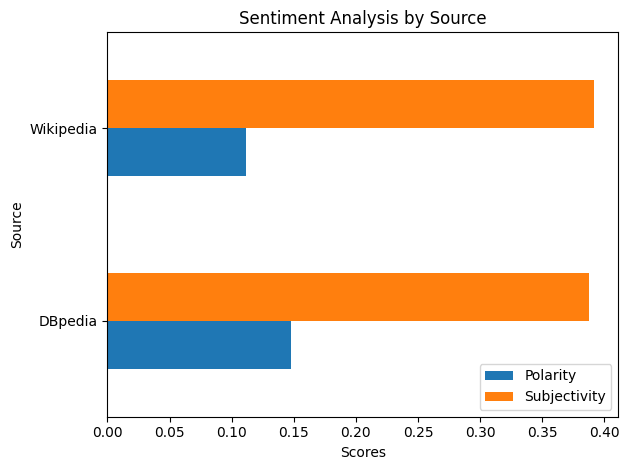

In [ ]:
import matplotlib.pyplot as plt

# Plot Polarity and Subjectivity grouped by Source
nimoy_df.plot.barh(x='Source', y=['Polarity', 'Subjectivity'])

plt.title('Sentiment Analysis by Source')
plt.xlabel('Scores')
plt.ylabel('Source')
plt.tight_layout()
plt.show()

### Comparing to Nearest Neighbors

In [ ]:
user_agent = "foobar"
wikip = wikipediaapi.Wikipedia(user_agent=user_agent)

topics = [
    "Leonard Nimoy", "Scott McGinnis", "Alan Howarth (composer)",
    "Branscombe Richmond", "Dayton Ward", "Dean Wesley Smith",
    "Marshall R. Teague", "Thomas Kopache", "Gary Graham",
    "Anthony Montgomery", "J. J. Abrams"
]

data = []

for topic in topics:
    try:
        page = wikip.page(topic)
        if page.exists():
            # Use dictionary keys as strings and pull the correct attributes
            data.append({"Topic": page.title, "Text": page.summary})
        else:
            print(f"Could not find entry for: {topic}")

    except Exception as e:
        print(f"Error processing {topic}: {e}")

df_wiki = pd.DataFrame(data)
print(df_wiki)

Could not find entry for: Scott McGinnis
                     Topic                                               Text
0            Leonard Nimoy  Leonard Simon Nimoy ( NEE-moy; March 26, 1931 ...
1  Alan Howarth (composer)  Alan Howarth is an American composer and sound...
2      Branscombe Richmond  Branscombe Richmond (born August 8, 1955) is a...
3              Dayton Ward  Dayton Ward (born June 7, 1967) is an American...
4        Dean Wesley Smith  Dean Wesley Smith (born November 10, 1950) is ...
5  Marshall Teague (actor)  Marshall R. Teague (born April 16, 1953) is an...
6           Thomas Kopache  Thomas Kopache (born October 17, 1945) is an A...
7              Gary Graham  Gary Rand Graham (June 6, 1950 – January 22, 2...
8       Anthony Montgomery  Anthony Dwayne Montgomery (born June 2, 1971) ...
9             J. J. Abrams  Jeffrey Jacob Abrams (; born June 27, 1966) is...


Interestingly, there is no wikipedia page (in english) for Scott McGinnis, I confirmed this.  The only one is in German.  https://de.wikipedia.org/wiki/Scott_McGinnis

So he has nothing to compare to in the new comparison.

In [ ]:
df_wiki['processed_text'] = (
  df_wiki['Text']
    .str.lower()
    .str.replace("\n", " ", regex=False)
    .str.replace("\'s", "", regex=False)
    .str.replace("\'", "", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace('"', "", regex=False)
)

print(df_wiki)

                     Topic                                               Text  \
0            Leonard Nimoy  Leonard Simon Nimoy ( NEE-moy; March 26, 1931 ...   
1  Alan Howarth (composer)  Alan Howarth is an American composer and sound...   
2      Branscombe Richmond  Branscombe Richmond (born August 8, 1955) is a...   
3              Dayton Ward  Dayton Ward (born June 7, 1967) is an American...   
4        Dean Wesley Smith  Dean Wesley Smith (born November 10, 1950) is ...   
5  Marshall Teague (actor)  Marshall R. Teague (born April 16, 1953) is an...   
6           Thomas Kopache  Thomas Kopache (born October 17, 1945) is an A...   
7              Gary Graham  Gary Rand Graham (June 6, 1950 – January 22, 2...   
8       Anthony Montgomery  Anthony Dwayne Montgomery (born June 2, 1971) ...   
9             J. J. Abrams  Jeffrey Jacob Abrams (; born June 27, 1966) is...   

                                      processed_text  
0  leonard simon nimoy  nee-moy; march 26, 1931 –... 

In [ ]:
vectorizer = BagOfWords(stop_words='english')
bow_vec2 = vectorizer.fit_transform(df_wiki['processed_text'])
bow_vec2

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 976 stored elements and shape (10, 741)>

In [ ]:
tf_idf_tran = TfidfTransformer()
tf_idf_wiki = tf_idf_tran.fit_transform(bow_vec2)
tf_idf_wiki

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 976 stored elements and shape (10, 741)>

In [ ]:
nn2 = NearestNeighbors().fit(tf_idf_wiki)

In [ ]:
nimoy2 = tf_idf_wiki[0]
nimoy2.shape

(1, 741)

In [ ]:
distances2, indices2 = nn2.kneighbors(
  X = nimoy2,
  n_neighbors = 10,
)

In [ ]:
distances2

array([[0.        , 1.30266013, 1.3058501 , 1.32136239, 1.33678751,
        1.33974411, 1.3492902 , 1.36651641, 1.37651878, 1.40764133]])

In [ ]:
indices2

array([[0, 9, 3, 7, 5, 1, 2, 8, 4, 6]])

In [ ]:
nearest_people2 = df_wiki.iloc[[0, 9, 3, 7, 5, 1, 2, 8, 4, 6], 0]

print(nearest_people2)

0              Leonard Nimoy
9               J. J. Abrams
3                Dayton Ward
7                Gary Graham
5    Marshall Teague (actor)
1    Alan Howarth (composer)
2        Branscombe Richmond
8         Anthony Montgomery
4          Dean Wesley Smith
6             Thomas Kopache
Name: Topic, dtype: object


In [ ]:
data2 = {
    "Person": [
        "Scott McGinnis", "Alan Howarth (composer)", "Branscombe Richmond",
        "Dayton Ward", "Dean Wesley Smith", "Marshall R. Teague",
        "Thomas Kopache", "Gary Graham", "Anthony Montgomery", "J. J. Abrams"
    ],
    "DBpedia": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Wikipedia": [10, 5, 6, 2, 8, 4, 9, 3, 7, 1],
    "Difference": [-9, -3, -3, 2, -3, 2, -2, 5, 2, 9]
}

# Create the DataFrame
df_diff = pd.DataFrame(data2)
df_diff

,Person,DBpedia,Wikipedia,Difference
0,Scott McGinnis,1,10,-9
1,Alan Howarth (composer),2,5,-3
2,Branscombe Richmond,3,6,-3
3,Dayton Ward,4,2,2
4,Dean Wesley Smith,5,8,-3
5,Marshall R. Teague,6,4,2
6,Thomas Kopache,7,9,-2
7,Gary Graham,8,3,5
8,Anthony Montgomery,9,7,2
9,J. J. Abrams,10,1,9


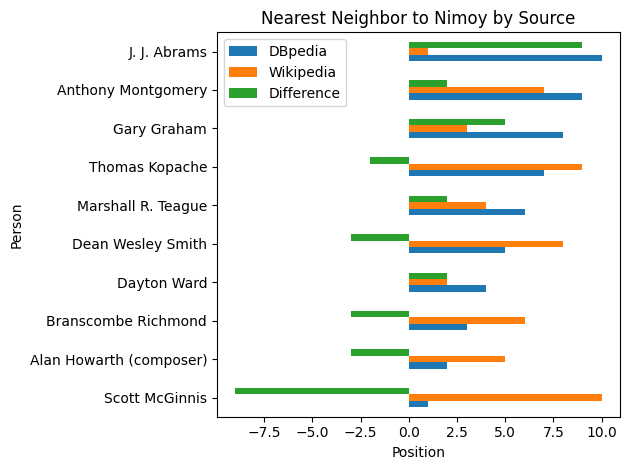

In [ ]:
df_diff.plot.barh(x='Person', y=['DBpedia', 'Wikipedia', 'Difference'])

plt.title('Nearest Neighbor to Nimoy by Source')
plt.xlabel('Position')
plt.ylabel('Person')
plt.tight_layout()
plt.show()

## Part 3) Interactive Notebook


Description provided to the class: Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.


In [ ]:
import ipywidgets as widgets
from ipywidgets import interact
from ipywidgets import IntText, interact

### Creating a searchable dataframe and Nearest Neighbors Search

This method allows the person to confirm the individual by showing the index and having the individual input the index

In [ ]:
@interact(search_query=widgets.Text(value="", description="Search Name:"))
def search_dataframe(search_query):

    filtered_df = df[
        df["name"].str.contains(search_query, case=False, na=False)
    ]

    if filtered_df.empty:
        print("No matches found.")
        return None
    return filtered_df


interactive(children=(Text(value='', description='Search Name:'), Output()), _dom_classes=('widget-interact',)…

In [ ]:
nn = NearestNeighbors(n_neighbors=11).fit(tf_idf_people)

def nearest_neighbors(person):
  person_id = tf_idf_people[person]

  distances, indices = nn.kneighbors(X=person_id)

  neighbor_indices = indices[0]
  nearest_people = df.iloc[neighbor_indices, 1]

  print(nearest_people)

interact(
    nearest_neighbors,
    person=IntText(
        value=0, min=0, description="Row Index:")
    );

interactive(children=(IntText(value=0, description='Row Index:'), Output()), _dom_classes=('widget-interact',)…

### Creating a complete interact

I struggled with the code for the complete interact, particularly with how to pass the indices output to the iloc, so I used Gemini on the web to help code this.  The comments are included to ensure understanding of the code.

In [ ]:
@interact(search_query=widgets.Text(value="", description="Search Name:"))
def search_dataframe(search_query):
    # 1. Prevent the model from running if the search box is empty
    if not search_query.strip():
        print("Please enter a name to find neighbors.")
        return

    # 2. Filter the dataframe to match the name
    filtered_df = df[
        df["name"].str.contains(search_query, case=False, na=False)
    ]

    if filtered_df.empty:
        print("No matches found.")
        return

    # 3. Capture the single integer index of the FIRST match
    captured_index = int(filtered_df.index[0])
    target_name = df.iloc[captured_index, 1]
    print(f"🎯 Target Person Found: {target_name} (Index: {captured_index})\n")

    # 4. Extract the feature row for this index from your training data Matrix
    target_features = tf_idf_people[captured_index].reshape(1, -1)

    # 5. Feed the extracted feature row to the model
    distances, indices = nn.kneighbors(
        X=target_features,
        n_neighbors=11,
    )

    # 6. Extract the actual names of the 11 nearest neighbors dynamically
    neighbor_indices = indices[0]
    nearest_people = df.iloc[neighbor_indices, 1]

    print("👥 Top 11 Nearest Neighbors:")
    return nearest_people

interactive(children=(Text(value='', description='Search Name:'), Output()), _dom_classes=('widget-interact',)…